<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/cnntest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


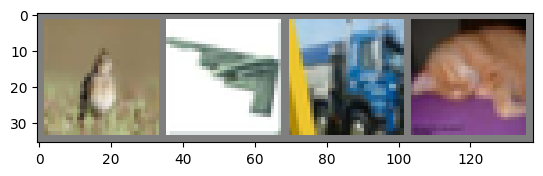

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyper-parameters
num_epochs = 5
batch_size = 4
learning_rate = 0.001

# dataset has PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

In [8]:
conv1 = nn.Conv2d(3, 6, 5)
pool = nn.MaxPool2d(2,2)
conv2 = nn.Conv2d(6, 16, 5)
# pool = nn.MaxPool2d(2,2)


In [11]:
print("images.shape")
print(images.shape)
x = conv1(images)
print("Shape after conv1")
print(x.shape)
x = pool(x)
print("Shape after pool")
print(x.shape)
x = conv2(x)
print("Shape after conv2")
print(x.shape)
x = pool(x)
print("Shape after pool")
print(x.shape)

images.shape
torch.Size([4, 3, 32, 32])
Shape after conv1
torch.Size([4, 6, 28, 28])
Shape after pool
torch.Size([4, 6, 14, 14])
Shape after conv2
torch.Size([4, 16, 10, 10])
Shape after pool
torch.Size([4, 16, 5, 5])


In [12]:
# Flatten = convert 3D tensor into 1D tensor
# That's why the input layer to Fully Connected NN layer
# is the flattened version of 3D tensor from previous layer -

In [13]:
# Here 16 * 5 * 5